In [14]:
from py_files.setup import *
setup_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Sectoral labour shares

Constructs sectoral labour shares $LS_C$ and $LS_I$ following GG-B using the Leontief inverse to capture labour embodied in all intermediate inputs.

Let $a_{ij}$ be the entry of the intermediate use matrix $\mathbf{A}$ and $\mathbf{L} = (\mathbf{I} - \mathbf{A})^{-1}$ the Leontief inverse. Setting $\ell_i = CE_i / x_i$ as direct labour compensation per unit of gross output, the consolidated labour share of industry $i$ is

$$
    LS_i = \sum_{k=1}^{39} \ell_k\, L_{ki}.
$$

Using the grouping map $g:\{1,\ldots,69\} \to \{1,\ldots,39\}$ — due to the difference in industry detail between `NAIO1F` and `NABP36` — the expenditure weights aggregating from the industry to the sectoral level are

$$
    w_{Cj} = \frac{\sum_{i=1}^{69}(C_i+G_i)\,\mathbb{1}[g(i)=j]}{\sum_{i=1}^{69}(C_i+G_i)}, \qquad
    w_{Ij} = \frac{\sum_{i=1}^{69} I_i\,\mathbb{1}[g(i)=j]}{\sum_{i=1}^{69} I_i},
$$

and the sectoral labour shares follow as

$$
    LS_C = \sum_{j=1}^{39} w_{Cj}\cdot LS_j, \qquad LS_I = \sum_{j=1}^{39} w_{Ij}\cdot LS_j.
$$

The notebook calls `LS_aggregator` from the python library. A direct variant — replacing $LS_i$ with $CE_i / GVA_i$ and bypassing the Leontief consolidation — is computed alongside for comparison.

In [15]:
# 1. get Leontif inverse values
years = range(1966, 2025)

# Direct (existing, unchanged)
df_direct = sls.load_or_compute_ls_timeseries(
    years, kappa=0.6,
)

# Leontief
df_ts_leon = sls.load_or_compute_ls_timeseries(
    years, kappa=0.6, use_leontief=True,
)

Fetching industry labor shares from NABP36 …
  Saved NABP36 to 0_intermediate/direct_NX_cache\nabp36_labor_shares.parquet
  Loading year 1966 from cache …
  1966:  LS_C=0.572  LS_I=0.669  Δ=0.097
  Loading year 1967 from cache …
  1967:  LS_C=0.573  LS_I=0.684  Δ=0.112
  Loading year 1968 from cache …
  1968:  LS_C=0.579  LS_I=0.716  Δ=0.136
  Loading year 1969 from cache …
  1969:  LS_C=0.583  LS_I=0.748  Δ=0.165
  Loading year 1970 from cache …
  1970:  LS_C=0.586  LS_I=0.770  Δ=0.183
  Loading year 1971 from cache …
  1971:  LS_C=0.598  LS_I=0.741  Δ=0.144
  Loading year 1972 from cache …
  1972:  LS_C=0.602  LS_I=0.674  Δ=0.071
  Loading year 1973 from cache …
  1973:  LS_C=0.592  LS_I=0.700  Δ=0.108
  Loading year 1974 from cache …
  1974:  LS_C=0.610  LS_I=0.717  Δ=0.107
  Loading year 1975 from cache …
  1975:  LS_C=0.609  LS_I=0.696  Δ=0.087
  Loading year 1976 from cache …
  1976:  LS_C=0.607  LS_I=0.731  Δ=0.124
  Loading year 1977 from cache …
  1977:  LS_C=0.609  LS_I=0.725

*`1. labour share differential over time`*

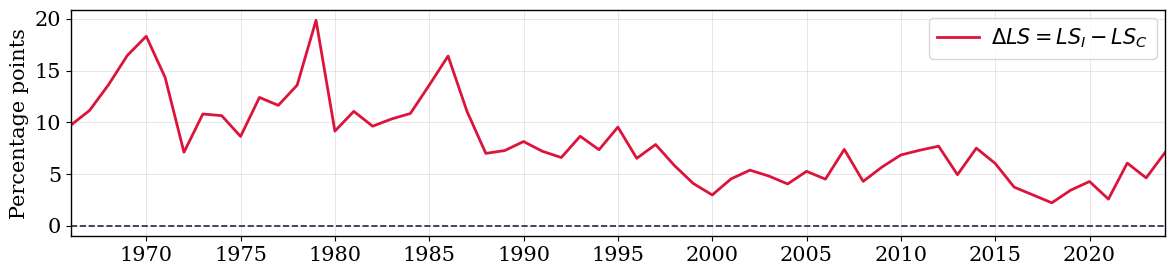

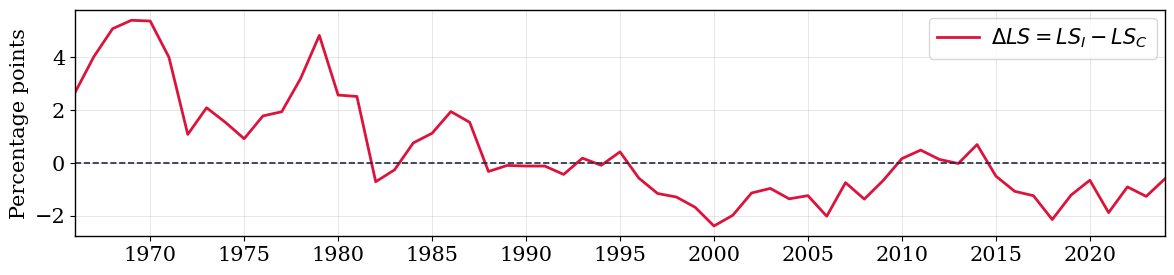

(<Figure size 1200x300 with 1 Axes>, <Axes: ylabel='Percentage points'>)

In [16]:
# 2. plot the difference between sectors
sls.plot_ls_difference(df_direct)
sls.plot_ls_difference(df_ts_leon)

*`2. diagnostic: industry-level weights and labour shares`*

Inspection for a single year. The Leontief-consolidated share assigns more weight to upstream industries, compressing $LS_I$ relative to the direct measure for investment-intensive sectors.

In [17]:
# 4. inspect industrylevel
diag = sls.inspect_year(2020, use_cache=True)
diag[['direct_ls', 'leontief_ls', 'w_C', 'w_I']]

  Loading NABP36 labor shares from cache …
  Loading year 2020 from cache …


,direct_ls,leontief_ls,w_C,w_I
parent,,,,
F,0.730906,0.491485,0.008403,0.393378
MA,0.742786,0.607532,0.001476,0.239099
G,0.624136,0.479729,0.136655,0.060869
CK,0.640436,0.354422,0.000439,0.034942
P,0.820632,0.729919,0.090542,0.033676
LA,0.189331,0.285609,0.002677,0.030483
MB,0.380567,0.293863,0.001426,0.026631
CF,0.209085,0.177497,0.001064,0.024337
JC,0.675686,0.532053,0.001528,0.024248


In [18]:
# 5. do weights sum to 1?
print(f"w_C sum:   {diag['w_C'].sum():.4f}")
print(f"w_I sum:   {diag['w_I'].sum():.4f}")

w_C sum:   1.0000
w_I sum:   1.0000


*`3. appendix table`*

Industry-level table aggregated to the 36-parent level. Columns report direct final-demand shares $(C, I^{\text{tan}}, I^{\text{intan}}, X)$, Leontief-consolidated labour shares $\ell_i^{\text{cons}}$, and size relative to GDP. Constructed from NABP36 merged with IO output requirements.

In [19]:
yr = il.load_or_compute_year(2024)
out_req = yr['output_requirements'].copy()
use_shares = yr['use_shares'].copy()
X = yr['X'].copy()

# add investment type classification
use_shares['investment_type'] = use_shares.index.map(var_groups.investment_type)
use_shares['parent'] = use_shares.index.map(var_groups.sub_to_parent)
out_req['parent'] = out_req.index.map(var_groups.sub_to_parent)
out_req['investment_type'] = out_req.index.map(var_groups.investment_type)

# split I into tangible and intangible at sub-industry level
tangible_types = ['structures', 'equipment']
intangible_types = ['intellectual_property', 'organizational']

out_req['I_tan']   = out_req['I'] * out_req['investment_type'].isin(tangible_types)
out_req['I_intan'] = out_req['I'] * out_req['investment_type'].isin(intangible_types)

# aggregate to parent
table = out_req.groupby('parent').sum()[['C', 'G', 'I_tan', 'I_intan', 'X']].copy()
table['total'] = table['C'] + table['G'] + table['I_tan'] + table['I_intan'] + table['X']
table['C (%)']         = ((table['C'] + table['G']) / table['total'] * 100).round(1)
table['Tangible (%)']  = (table['I_tan']   / table['total'] * 100).round(1)
table['Intangible (%)']= (table['I_intan'] / table['total'] * 100).round(1)
table['X (%)']         = (table['X'] / table['total'] * 100).round(1)

# size
gdp = il.fetch_gdp_data([2024]).iloc[0]
table['Uses/GDP (%)'] = (table['total'] / gdp * 100).round(1)

# Leontief-consolidated labour shares
df_ls = sls.fetch_industry_labor_shares()
df_ls_yr = df_ls[df_ls['year'] == 2024]
ls_cons = sls.consolidated_labor_shares(yr, df_ls_yr, use_leontief=True)
ls_cons.index = ls_cons.index.map(var_groups.sub_to_parent)
ls_parent = ls_cons.groupby(ls_cons.index).mean()
table['LS (%)'] = (ls_parent * 100).round(1)

# names and final order
table['Industry'] = table.index.map(var_groups.large_dict)
table = table.set_index('Industry')
table = table[['Uses/GDP (%)', 'C (%)', 'Tangible (%)', 'Intangible (%)', 'X (%)', 'LS (%)']].round(1)
table

  Loading year 2024 from cache …


,Uses/GDP (%),C (%),Tangible (%),Intangible (%),X (%),LS (%)
Industry,,,,,,
"Agriculture, forestry and fishing",0.9,19.3,0.4,0.0,80.3,31.8
Mining and quarrying,0.3,2.0,3.0,0.0,95.0,25.4
"Manufacture of food products, beverages and tobacco",5.2,24.3,1.1,0.0,74.6,32.5
Textiles and leather products,0.3,14.5,3.2,0.0,82.3,31.4
Wood and paper products and printing,0.4,6.0,2.6,0.0,91.3,40.6
Oil refinery etc.,0.7,38.1,0.0,0.0,61.8,8.7
Manufacture of chemicals,1.5,2.3,5.9,0.0,91.8,22.5
Pharmaceuticals,11.2,0.4,0.0,8.1,91.6,13.8
"Manufacture of plastic, glass and concrete",0.7,7.2,2.5,0.0,90.3,37.3
